# 06 - Grad-CAM sur SmallCNN avec module projet


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print('PROJECT_ROOT =', PROJECT_ROOT)
print('SRC_DIR =', SRC_DIR)


PROJECT_ROOT = /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification
SRC_DIR = /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/src


In [2]:
import random
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

from brain_tumor_mri.data.dataset import BrainMRIDataset
from brain_tumor_mri.models.builder import build_model
from brain_tumor_mri.training.engine import predict_probabilities
from brain_tumor_mri.utils import get_device, set_seed
from brain_tumor_mri.evaluation.gradcam import GradCAM, disable_inplace_relu, load_original_rgb, make_input_tensor, overlay_heatmap


In [3]:
CONFIG = {
    'seed': 42,
    'model_name': 'cnn_small',
    'num_classes': 2,
    'pretrained': False,
    'img_size': 224,
    'checkpoint_name': 'best_smallcnn_baseline.pt',
    'threshold': 0.20,
    'num_examples_per_group': 3,
}
CONFIG


{'seed': 42,
 'model_name': 'cnn_small',
 'num_classes': 2,
 'pretrained': False,
 'img_size': 224,
 'checkpoint_name': 'best_smallcnn_baseline.pt',
 'threshold': 0.2,
 'num_examples_per_group': 3}

In [4]:
set_seed(CONFIG['seed'])
device = get_device()
TEST_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'brain_mri' / 'Testing'
CHECKPOINT_PATH = PROJECT_ROOT / 'artifacts' / 'checkpoints' / CONFIG['checkpoint_name']
print('Device:', device)
print('TEST_ROOT =', TEST_ROOT)
print('CHECKPOINT_PATH =', CHECKPOINT_PATH)


Device: cpu
TEST_ROOT = /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/data/raw/brain_mri/Testing
CHECKPOINT_PATH = /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/artifacts/checkpoints/best_smallcnn_baseline.pt


In [5]:
eval_tfms = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
])
test_dataset = BrainMRIDataset(TEST_ROOT, transform=eval_tfms)
print('Test size:', len(test_dataset))
print('Distribution:', Counter(test_dataset.get_labels()))


Test size: 394
Distribution: Counter({1: 289, 0: 105})


In [6]:
model = build_model(model_name=CONFIG['model_name'], num_classes=CONFIG['num_classes'], pretrained=CONFIG['pretrained'], img_size=CONFIG['img_size']).to(device)
ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
    model.load_state_dict(ckpt['model_state_dict'])
else:
    model.load_state_dict(ckpt)
disable_inplace_relu(model)
model.eval()
print('Checkpoint loaded successfully.')


Checkpoint loaded successfully.


In [7]:
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)
y_true, y_probs = predict_probabilities(model=model, loader=test_loader, device=device)
y_true = np.array(y_true)
y_probs = np.array(y_probs)
y_pred = (y_probs >= CONFIG['threshold']).astype(int)
print('Threshold used for case selection:', CONFIG['threshold'])


Threshold used for case selection: 0.2


In [8]:
tp_idx = np.where((y_true == 1) & (y_pred == 1))[0].tolist()
tn_idx = np.where((y_true == 0) & (y_pred == 0))[0].tolist()
fp_idx = np.where((y_true == 0) & (y_pred == 1))[0].tolist()
fn_idx = np.where((y_true == 1) & (y_pred == 0))[0].tolist()
print('TP:', len(tp_idx))
print('TN:', len(tn_idx))
print('FP:', len(fp_idx))
print('FN:', len(fn_idx))


TP: 188
TN: 78
FP: 27
FN: 101


In [17]:
rng = random.Random(CONFIG['seed'])

def sample_indices(indices, n=3):
    if len(indices) == 0:
        return []
    if len(indices) <= n:
        return indices
    return rng.sample(indices, n)

selected = {
    'TP': sample_indices(tp_idx, CONFIG['num_examples_per_group']),
    'TN': sample_indices(tn_idx, CONFIG['num_examples_per_group']),
    'FP': sample_indices(fp_idx, CONFIG['num_examples_per_group']),
    'FN': sample_indices(fn_idx, CONFIG['num_examples_per_group']),
}
selected


{'TP': [355, 51, 8],
 'TN': [262, 258, 255],
 'FP': [228, 307, 225],
 'FN': [335, 379, 176]}

In [18]:
target_layer = model.features[-4]
gradcam = GradCAM(model, target_layer)
print(target_layer)


Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


In [19]:
def show_gradcam_for_index(idx, title_prefix=''):
    path, true_label = test_dataset.samples[idx]
    input_tensor = make_input_tensor(path, eval_tfms, device)
    cam, pred_class, pred_prob, probs = gradcam.generate(input_tensor)
    original = load_original_rgb(path)
    overlay = overlay_heatmap(original, cam)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(original)
    axes[0].set_title('Original')
    axes[0].axis('off')
    axes[1].imshow(cam, cmap='jet')
    axes[1].set_title('Grad-CAM')
    axes[1].axis('off')
    axes[2].imshow(overlay)
    axes[2].set_title('Overlay')
    axes[2].axis('off')
    plt.suptitle(f"{title_prefix} | true={true_label} | pred={pred_class} | p(tumor)={probs[1]:.4f} | idx={idx}", fontsize=11)
    plt.tight_layout()
    plt.show()



===== TP =====


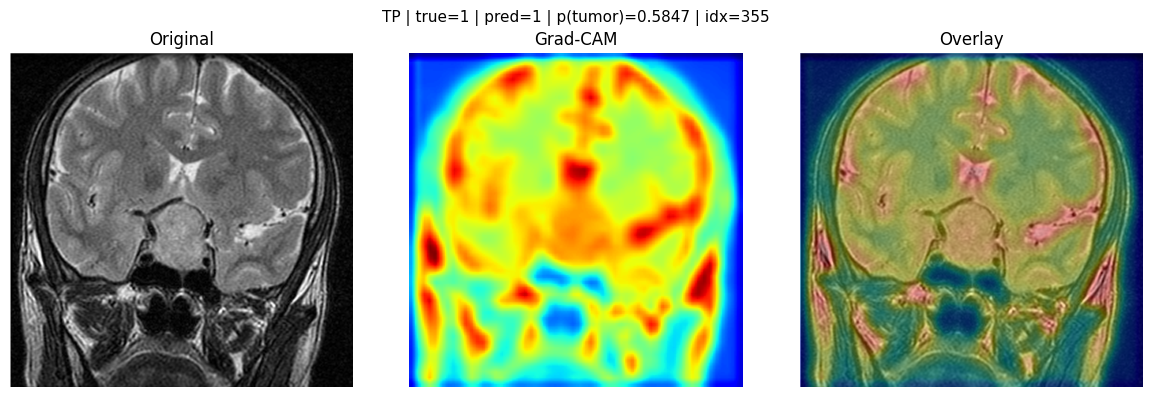

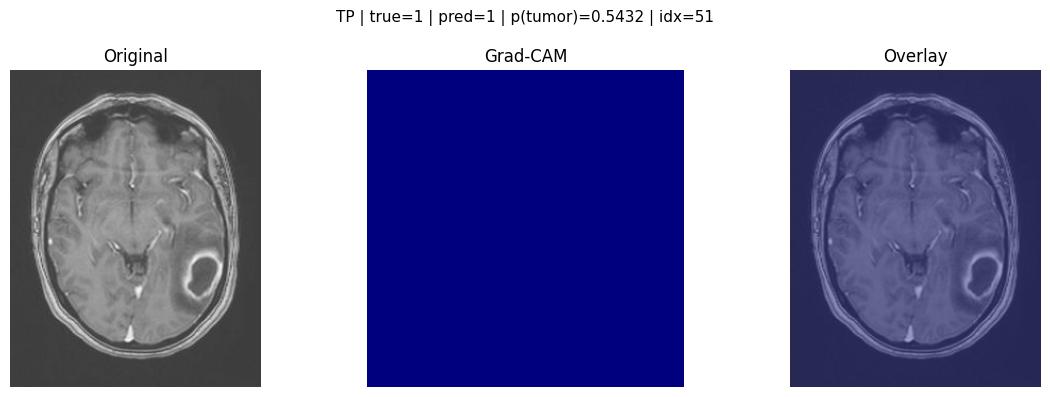

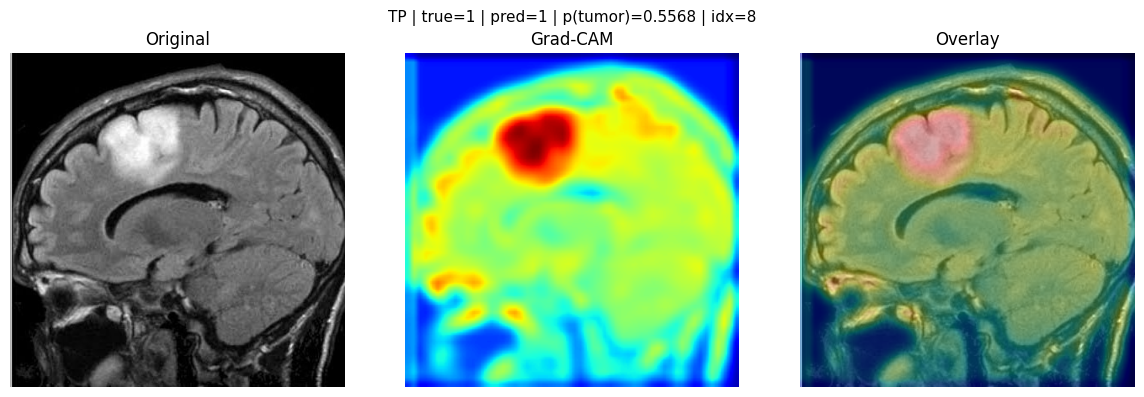


===== TN =====


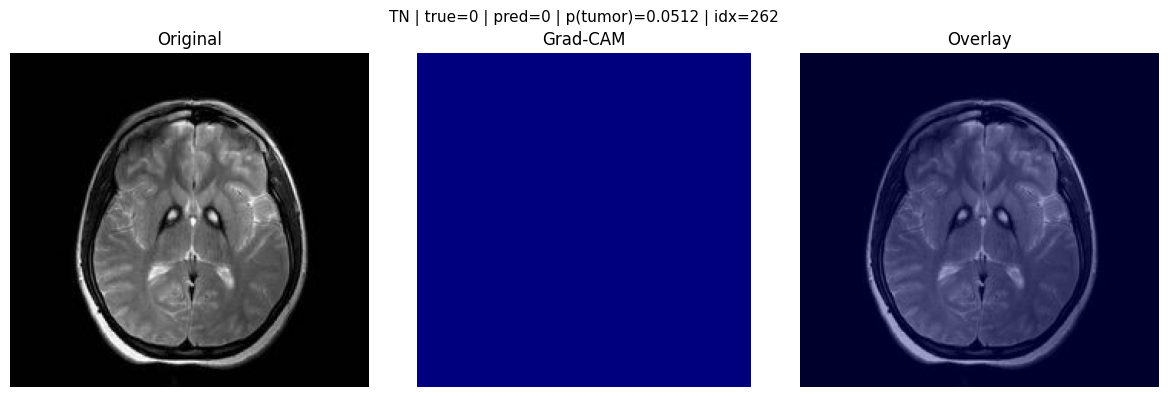

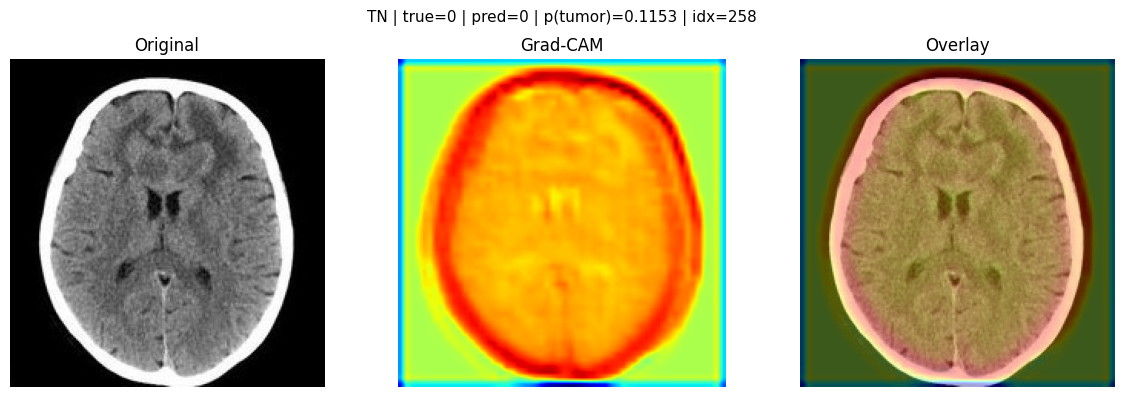

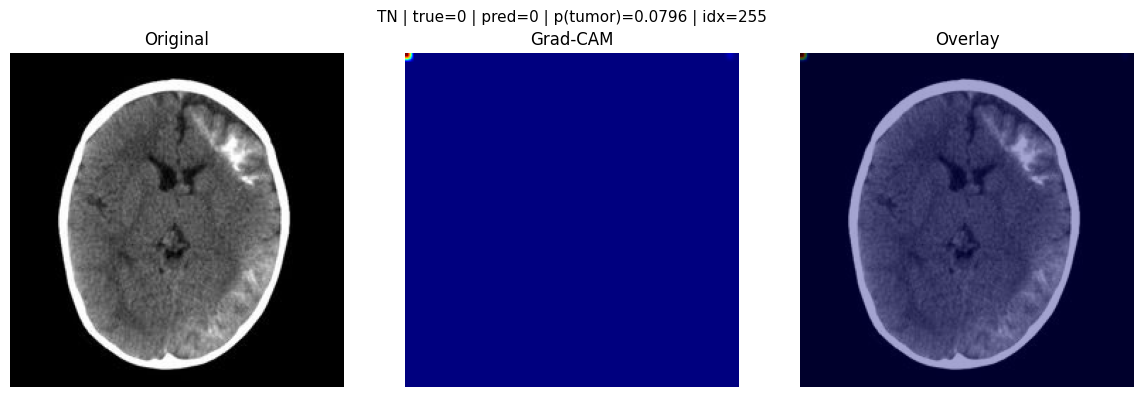


===== FP =====


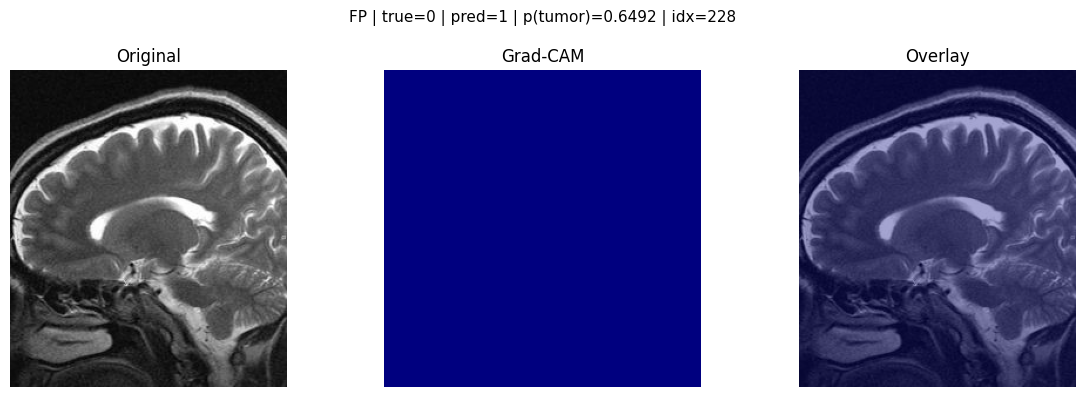

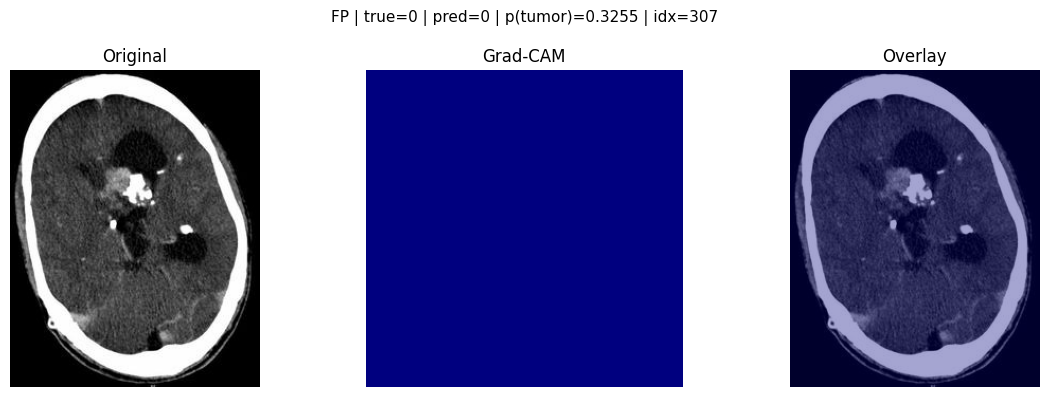

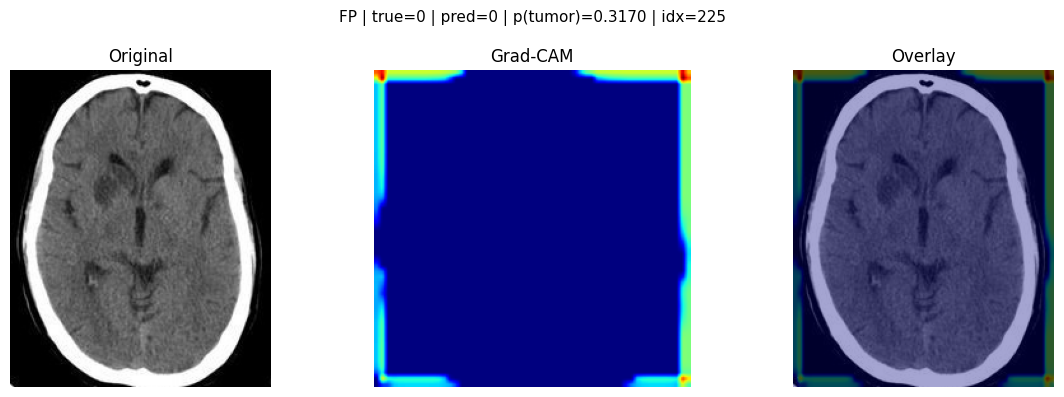


===== FN =====


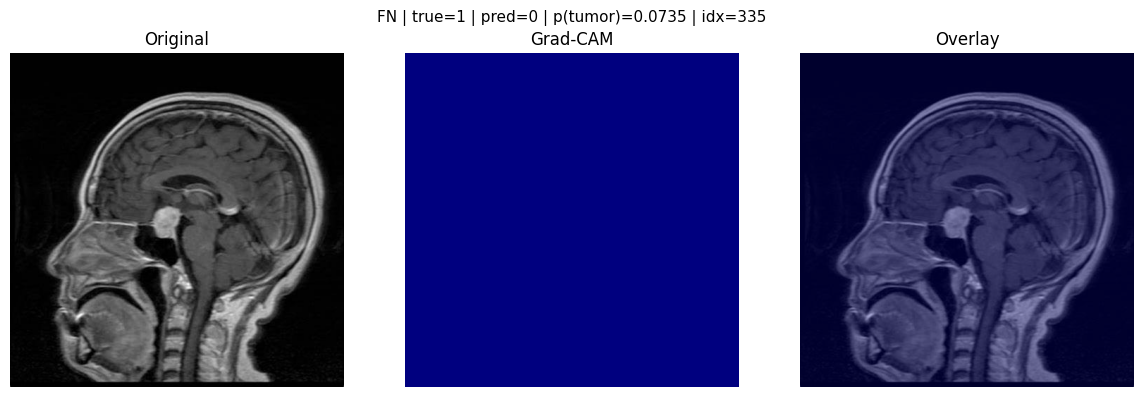

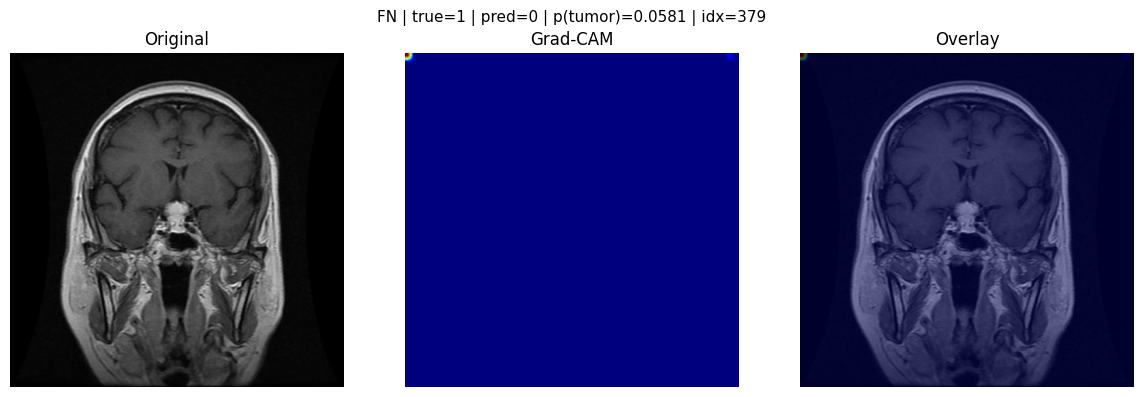

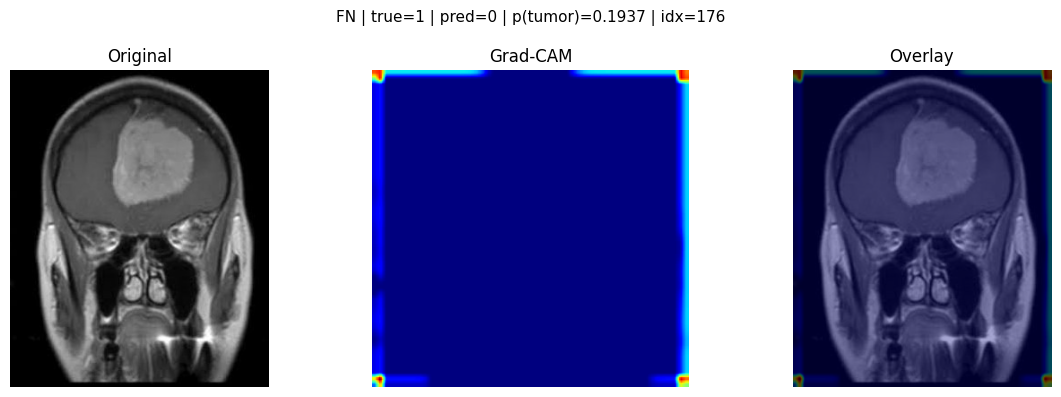

In [20]:
for group_name, idx_list in selected.items():
    print(f'\n===== {group_name} =====')
    if len(idx_list) == 0:
        print('No examples found.')
        continue
    for idx in idx_list:
        show_gradcam_for_index(idx, title_prefix=group_name)
